In [413]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [414]:
nav_history = pd.read_csv(
    "../data/processed/nav_history.csv"
)

In [415]:
nav_history.head()

,date,nav,source_file
0,01-06-2026,103.0948,icici_bluechip.csv
1,31-05-2026,104.3083,icici_bluechip.csv
2,29-05-2026,104.3129,icici_bluechip.csv
3,27-05-2026,105.9296,icici_bluechip.csv
4,26-05-2026,105.5115,icici_bluechip.csv


In [416]:
nav_history.columns

Index(['date', 'nav', 'source_file'], dtype='object')

In [417]:
nav_history.shape

(19798, 3)

In [418]:
nav_history = nav_history[nav_history["nav"] > 0]

In [419]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"],
    dayfirst=True
)

nav_history.head()

,date,nav,source_file
0,2026-06-01,103.0948,icici_bluechip.csv
1,2026-05-31,104.3083,icici_bluechip.csv
2,2026-05-29,104.3129,icici_bluechip.csv
3,2026-05-27,105.9296,icici_bluechip.csv
4,2026-05-26,105.5115,icici_bluechip.csv


In [420]:
nav_history = nav_history.sort_values(
    ["source_file", "date"]
)

nav_history.head()

,date,nav,source_file
6871,2012-12-31,23.9920,axis_bluechip.csv
6870,2013-01-01,23.9979,axis_bluechip.csv
6869,2013-01-02,24.0036,axis_bluechip.csv
6868,2013-01-03,24.0092,axis_bluechip.csv
6867,2013-01-04,24.0147,axis_bluechip.csv


In [421]:
nav_history["daily_return"] = (
    nav_history
    .groupby("source_file")["nav"]
    .pct_change()
)

nav_history.head()

,date,nav,source_file,daily_return
6871,2012-12-31,23.9920,axis_bluechip.csv,NaN
6870,2013-01-01,23.9979,axis_bluechip.csv,0.000246
6869,2013-01-02,24.0036,axis_bluechip.csv,0.000238
6868,2013-01-03,24.0092,axis_bluechip.csv,0.000233
6867,2013-01-04,24.0147,axis_bluechip.csv,0.000229


In [422]:
nav_history[[
    "date",
    "nav",
    "source_file",
    "daily_return"
]].head()

,date,nav,source_file,daily_return
6871,2012-12-31,23.9920,axis_bluechip.csv,NaN
6870,2013-01-01,23.9979,axis_bluechip.csv,0.000246
6869,2013-01-02,24.0036,axis_bluechip.csv,0.000238
6868,2013-01-03,24.0092,axis_bluechip.csv,0.000233
6867,2013-01-04,24.0147,axis_bluechip.csv,0.000229


In [423]:
nav_history["source_file"].nunique()

6

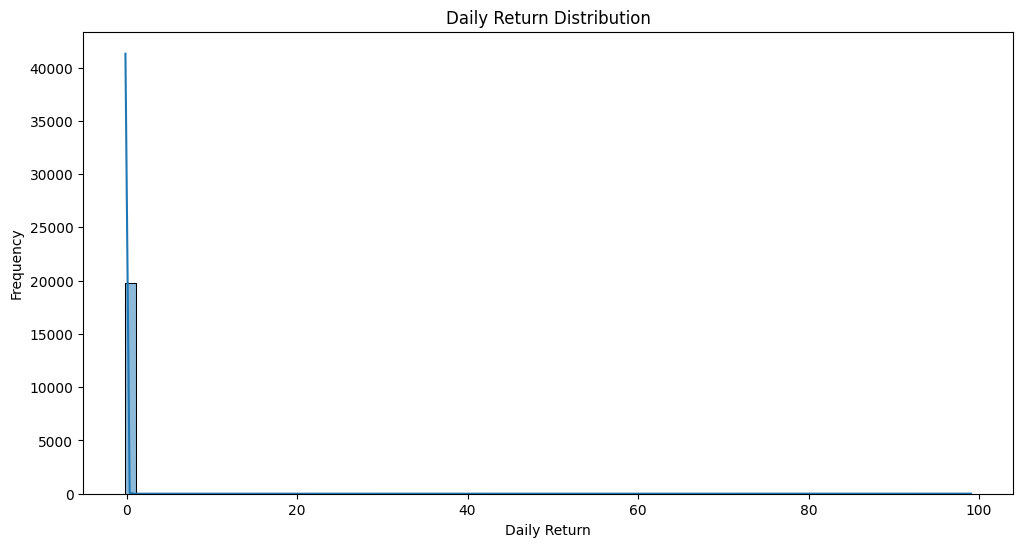

In [424]:
plt.figure(figsize=(12,6))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=80,
    kde=True
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

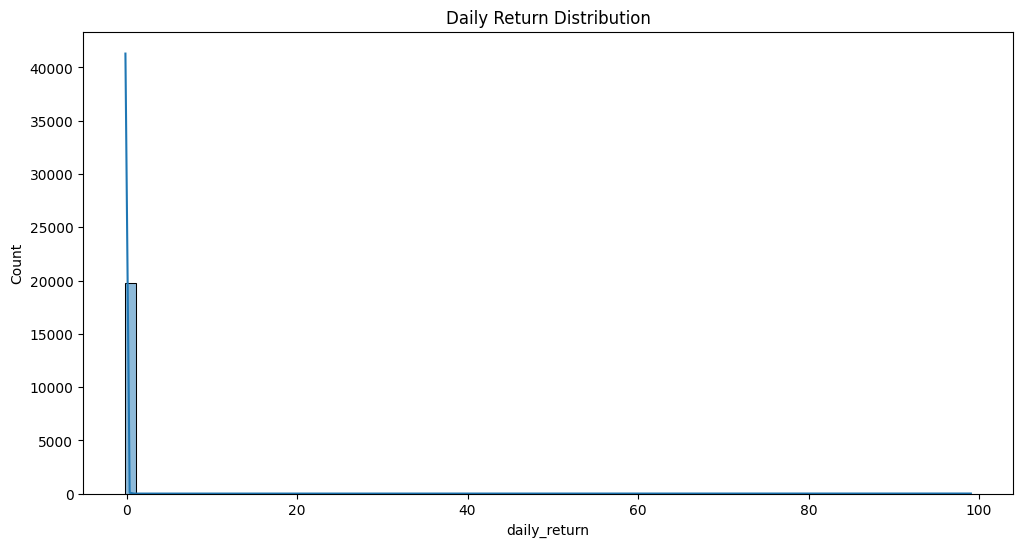

In [425]:
plt.figure(figsize=(12,6))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=80,
    kde=True
)

plt.title("Daily Return Distribution")

plt.savefig(
    "../reports/return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [426]:
def calculate_cagr(
    start_nav,
    end_nav,
    years
):
    return (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

In [427]:
cagr_results = []

for fund in nav_history["source_file"].unique():

    df = nav_history[
        nav_history["source_file"] == fund
    ]

    start_nav = df["nav"].iloc[0]

    end_nav = df["nav"].iloc[-1]

    years = (
        (
            df["date"].max()
            -
            df["date"].min()
        ).days
    ) / 365

    cagr = calculate_cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_results.append(
        [fund, cagr]
    )

In [428]:
cagr_df = pd.DataFrame(
    cagr_results,
    columns=["fund","cagr"]
)

cagr_df.sort_values(
    "cagr",
    ascending=False
)

,fund,cagr
0,axis_bluechip.csv,0.511705
1,hdfc_top100_nav.csv,0.238945
3,kotak_bluechip.csv,0.168548
2,icici_bluechip.csv,0.154329
4,nippon_largecap.csv,0.151166
5,sbi_bluechip.csv,0.001218


In [429]:
rf = 0.065

In [430]:
def sharpe_ratio(returns):

    annual_return = (
        returns.mean() * 252
    )

    annual_volatility = (
        returns.std() * np.sqrt(252)
    )

    return (
        annual_return - rf
    ) / annual_volatility

In [431]:
sharpe_results = []

for fund in nav_history["source_file"].unique():

    returns = nav_history[
        nav_history["source_file"] == fund
    ]["daily_return"].dropna()

    sharpe = sharpe_ratio(
        returns
    )

    sharpe_results.append(
        [fund, sharpe]
    )

In [432]:
sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "fund",
        "sharpe"
    ]
)

sharpe_df.sort_values(
    "sharpe",
    ascending=False
)

,fund,sharpe
1,hdfc_top100_nav.csv,1.090510
3,kotak_bluechip.csv,0.690107
2,icici_bluechip.csv,0.611662
4,nippon_largecap.csv,0.559704
0,axis_bluechip.csv,0.265971
5,sbi_bluechip.csv,-0.686182


In [433]:
def sortino_ratio(returns):

    downside = returns[
        returns < 0
    ]

    annual_return = (
        returns.mean() * 252
    )

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    return (
        annual_return - rf
    ) / downside_std

In [434]:
sortino_results = []

for fund in nav_history["source_file"].unique():

    returns = nav_history[
        nav_history["source_file"] == fund
    ]["daily_return"].dropna()

    sortino = sortino_ratio(
        returns
    )

    sortino_results.append(
        [fund, sortino]
    )

In [435]:
sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "fund",
        "sortino"
    ]
)

sortino_df.sort_values(
    "sortino",
    ascending=False
)

,fund,sortino
0,axis_bluechip.csv,648.062253
1,hdfc_top100_nav.csv,1.319979
3,kotak_bluechip.csv,0.802476
2,icici_bluechip.csv,0.760575
4,nippon_largecap.csv,0.693775
5,sbi_bluechip.csv,-0.388909


In [436]:
def max_drawdown(nav):

    running_max = nav.cummax()

    drawdown = (
        nav / running_max
    ) - 1

    return drawdown.min()

In [437]:
drawdown_results = []

for fund in nav_history["source_file"].unique():

    df = nav_history[
        nav_history["source_file"] == fund
    ]

    dd = max_drawdown(
        df["nav"]
    )

    drawdown_results.append(
        [fund, dd]
    )

In [438]:
drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "fund",
        "max_drawdown"
    ]
)

drawdown_df.sort_values(
    "max_drawdown"
)

,fund,max_drawdown
1,hdfc_top100_nav.csv,-0.402601
4,nippon_largecap.csv,-0.399608
5,sbi_bluechip.csv,-0.366517
2,icici_bluechip.csv,-0.335099
3,kotak_bluechip.csv,-0.334299
0,axis_bluechip.csv,-0.013924


In [439]:
for fund in nav_history["source_file"].unique():

    print("\n", fund)

    df = nav_history[
        nav_history["source_file"] == fund
    ]

    print(df.head())
    print(df.tail())


 axis_bluechip.csv
           date      nav        source_file  daily_return
6871 2012-12-31  23.9920  axis_bluechip.csv           NaN
6870 2013-01-01  23.9979  axis_bluechip.csv      0.000246
6869 2013-01-02  24.0036  axis_bluechip.csv      0.000238
6868 2013-01-03  24.0092  axis_bluechip.csv      0.000233
6867 2013-01-04  24.0147  axis_bluechip.csv      0.000229
           date        nav        source_file  daily_return
3311 2026-05-25  6144.8478  axis_bluechip.csv      0.000360
3310 2026-05-26  6144.0004  axis_bluechip.csv     -0.000138
3309 2026-05-27  6146.6118  axis_bluechip.csv      0.000425
3308 2026-05-29  6151.1139  axis_bluechip.csv      0.000732
3307 2026-06-01  6156.7532  axis_bluechip.csv      0.000917

 hdfc_top100_nav.csv
            date      nav          source_file  daily_return
16496 2013-11-18  13.0894  hdfc_top100_nav.csv           NaN
16495 2013-11-19  13.1068  hdfc_top100_nav.csv      0.001329
16494 2013-11-20  12.9549  hdfc_top100_nav.csv     -0.011589
16493 

In [440]:
nav_history.groupby(
    "source_file"
)["nav"].agg(
    ["min","max","count"]
)

,min,max,count
source_file,,,
axis_bluechip.csv,23.9920,6156.7532,3565
hdfc_top100_nav.csv,12.7775,214.6767,3091
icici_bluechip.csv,13.6318,113.6849,3306
kotak_bluechip.csv,30.5643,281.1083,3301
nippon_largecap.csv,12.2191,106.1272,3298
sbi_bluechip.csv,102.2299,161.3775,3236


In [441]:
nav_history[
    nav_history["source_file"]=="icici_bluechip.csv"
].sort_values("date")

,date,nav,source_file,daily_return
3306,2013-01-02,15.0253,icici_bluechip.csv,NaN
3305,2013-01-03,15.0737,icici_bluechip.csv,0.003221
3304,2013-01-04,15.0702,icici_bluechip.csv,-0.000232
3303,2013-01-07,15.0913,icici_bluechip.csv,0.001400
3302,2013-01-08,15.1146,icici_bluechip.csv,0.001544
...,...,...,...,...
4,2026-05-26,105.5115,icici_bluechip.csv,-0.003873
3,2026-05-27,105.9296,icici_bluechip.csv,0.003963
2,2026-05-29,104.3129,icici_bluechip.csv,-0.015262
1,2026-05-31,104.3083,icici_bluechip.csv,-0.000044


In [442]:
nav_history[
    (nav_history["source_file"]=="icici_bluechip.csv")
    &
    (nav_history["nav"]==0)
]

,date,nav,source_file,daily_return


In [443]:
nav_history[
    (nav_history["source_file"]=="icici_bluechip.csv")
    &
    (nav_history["nav"]<=1)
]

,date,nav,source_file,daily_return


In [444]:
nav_history = nav_history[
    nav_history["nav"] > 0
]

nav_history.shape

(19797, 4)

In [445]:
nav_history[
    (nav_history["source_file"]=="icici_bluechip.csv")
    &
    (nav_history["nav"]==0)
]

,date,nav,source_file,daily_return


In [446]:
nav_history = nav_history.sort_values(
    ["source_file","date"]
)

nav_history["daily_return"] = (
    nav_history.groupby("source_file")["nav"]
    .pct_change()
)

In [447]:
cagr_df.sort_values(
    "cagr",
    ascending=False
)

,fund,cagr
0,axis_bluechip.csv,0.511705
1,hdfc_top100_nav.csv,0.238945
3,kotak_bluechip.csv,0.168548
2,icici_bluechip.csv,0.154329
4,nippon_largecap.csv,0.151166
5,sbi_bluechip.csv,0.001218


In [448]:
sharpe_df.sort_values(
    "sharpe",
    ascending=False
)

,fund,sharpe
1,hdfc_top100_nav.csv,1.090510
3,kotak_bluechip.csv,0.690107
2,icici_bluechip.csv,0.611662
4,nippon_largecap.csv,0.559704
0,axis_bluechip.csv,0.265971
5,sbi_bluechip.csv,-0.686182


In [449]:
nav_history[
    nav_history["source_file"]=="icici_bluechip.csv"
]["daily_return"].describe()

count    3305.000000
mean        0.000630
std         0.009649
min        -0.122362
25%        -0.004013
50%         0.000945
75%         0.005764
max         0.065615
Name: daily_return, dtype: float64

In [450]:
nav_history[
    nav_history["source_file"]=="icici_bluechip.csv"
]["daily_return"].isna().sum()

np.int64(1)

In [451]:
icici = nav_history[
    nav_history["source_file"]=="icici_bluechip.csv"
]

icici[["date","nav","daily_return"]].head(20)

,date,nav,daily_return
3306,2013-01-02,15.0253,NaN
3305,2013-01-03,15.0737,0.003221
3304,2013-01-04,15.0702,-0.000232
3303,2013-01-07,15.0913,0.001400
3302,2013-01-08,15.1146,0.001544
3301,2013-01-09,15.0517,-0.004162
3300,2013-01-10,15.0619,0.000678
3299,2013-01-11,14.8886,-0.011506
3298,2013-01-14,14.9767,0.005917
3297,2013-01-15,14.9813,0.000307


In [452]:
icici[["date","nav","daily_return"]].tail(20)

,date,nav,daily_return
19,2026-05-05,105.8387,0.000887
18,2026-05-06,107.3354,0.014141
17,2026-05-07,107.6729,0.003144
16,2026-05-08,107.1500,-0.004856
15,2026-05-11,105.6066,-0.014404
14,2026-05-12,103.3384,-0.021478
13,2026-05-13,103.3960,0.000557
12,2026-05-14,104.5531,0.011191
11,2026-05-15,104.2918,-0.002499
10,2026-05-18,104.1556,-0.001306


In [453]:
nav_history = nav_history.sort_values(
    ["source_file","date"]
)

nav_history["daily_return"] = (
    nav_history.groupby("source_file")["nav"]
    .pct_change()
)

In [454]:
nav_history[
    nav_history["source_file"]=="icici_bluechip.csv"
]["daily_return"].describe()

count    3305.000000
mean        0.000630
std         0.009649
min        -0.122362
25%        -0.004013
50%         0.000945
75%         0.005764
max         0.065615
Name: daily_return, dtype: float64

In [455]:
returns = nav_history[
    nav_history["source_file"]=="icici_bluechip.csv"
]["daily_return"]

print("Mean:", returns.mean())
print("Std :", returns.std())

Mean: 0.0006297248233612701
Std : 0.009649052144817826


In [456]:
rf = 0.065

returns = nav_history[
    nav_history["source_file"]=="icici_bluechip.csv"
]["daily_return"].dropna()

sharpe = (
    (returns.mean()*252 - rf)
    /
    (returns.std()*np.sqrt(252))
)

print(sharpe)

0.6116617932271303


In [457]:
nav_history[
    nav_history["source_file"]=="icici_bluechip.csv"
]["daily_return"].isna().sum()

np.int64(1)

In [458]:
returns = nav_history[
    nav_history["source_file"]=="icici_bluechip.csv"
]["daily_return"].dropna()

print("Mean:", returns.mean())
print("Std:", returns.std())
print("Count:", len(returns))

annual_return = returns.mean() * 252
annual_volatility = returns.std() * np.sqrt(252)

print("Annual Return:", annual_return)
print("Annual Volatility:", annual_volatility)

print("Sharpe:", (annual_return - 0.065)/annual_volatility)

Mean: 0.0006297248233612701
Std: 0.009649052144817826
Count: 3305
Annual Return: 0.15869065548704006
Annual Volatility: 0.1531739541760942
Sharpe: 0.6116617932271303


In [459]:
sharpe_results = []

In [460]:
for fund in nav_history["source_file"].unique():

    returns = nav_history[
        nav_history["source_file"] == fund
    ]["daily_return"].dropna()

    sharpe = sharpe_ratio(returns)

    sharpe_results.append([fund, sharpe])

In [461]:
len(sharpe_results)

6

In [462]:
sharpe_results

[['axis_bluechip.csv', np.float64(0.265970556340899)],
 ['hdfc_top100_nav.csv', np.float64(1.0905104257321685)],
 ['icici_bluechip.csv', np.float64(0.6116617932271303)],
 ['kotak_bluechip.csv', np.float64(0.6901071014907375)],
 ['nippon_largecap.csv', np.float64(0.5597036256125437)],
 ['sbi_bluechip.csv', np.float64(-0.6861823212684862)]]

In [463]:
sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["fund", "sharpe"]
)

sharpe_df.sort_values(
    "sharpe",
    ascending=False
)

,fund,sharpe
1,hdfc_top100_nav.csv,1.090510
3,kotak_bluechip.csv,0.690107
2,icici_bluechip.csv,0.611662
4,nippon_largecap.csv,0.559704
0,axis_bluechip.csv,0.265971
5,sbi_bluechip.csv,-0.686182


In [464]:
benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices.csv"
)

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [465]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [466]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [467]:
benchmark["index_name"].value_counts()

index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64

In [468]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [469]:
nifty100.columns

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='object')

In [471]:
from scipy.stats import linregress

In [472]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

In [473]:
alpha_beta_results = []

for fund in nav_history["source_file"].unique():

    fund_df = nav_history[
        nav_history["source_file"] == fund
    ].copy()

    merged = pd.merge(
        fund_df,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = slope
    alpha = intercept * 252

    alpha_beta_results.append(
        [fund, alpha, beta]
    )

In [474]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "fund",
        "alpha",
        "beta"
    ]
)

alpha_beta_df

,fund,alpha,beta
0,axis_bluechip.csv,0.068413,-0.000470
1,hdfc_top100_nav.csv,0.125547,-0.001066
2,icici_bluechip.csv,0.065362,-0.001231
3,kotak_bluechip.csv,0.172714,0.031597
4,nippon_largecap.csv,0.148665,-0.010954
5,sbi_bluechip.csv,-0.027711,-0.001776


In [475]:
scorecard = cagr_df.copy()

scorecard["sharpe"] = sharpe_df["sharpe"].values
scorecard["alpha"] = alpha_beta_df["alpha"].values
scorecard["max_drawdown"] = drawdown_df["max_drawdown"].values

scorecard

,fund,cagr,sharpe,alpha,max_drawdown
0,axis_bluechip.csv,0.511705,0.265971,0.068413,-0.013924
1,hdfc_top100_nav.csv,0.238945,1.090510,0.125547,-0.402601
2,icici_bluechip.csv,0.154329,0.611662,0.065362,-0.335099
3,kotak_bluechip.csv,0.168548,0.690107,0.172714,-0.334299
4,nippon_largecap.csv,0.151166,0.559704,0.148665,-0.399608
5,sbi_bluechip.csv,0.001218,-0.686182,-0.027711,-0.366517


In [476]:
scorecard["cagr_rank"] = scorecard["cagr"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

scorecard["dd_rank"] = scorecard["max_drawdown"].rank(
    ascending=False
)

scorecard.head()

,fund,cagr,sharpe,alpha,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,dd_rank
0,axis_bluechip.csv,0.511705,0.265971,0.068413,-0.013924,1.0,5.0,4.0,1.0
1,hdfc_top100_nav.csv,0.238945,1.090510,0.125547,-0.402601,2.0,1.0,3.0,6.0
2,icici_bluechip.csv,0.154329,0.611662,0.065362,-0.335099,4.0,3.0,5.0,3.0
3,kotak_bluechip.csv,0.168548,0.690107,0.172714,-0.334299,3.0,2.0,1.0,2.0
4,nippon_largecap.csv,0.151166,0.559704,0.148665,-0.399608,5.0,4.0,2.0,5.0


In [477]:
scorecard["score"] = (
    scorecard["cagr_rank"] * 0.40
    +
    scorecard["sharpe_rank"] * 0.30
    +
    scorecard["alpha_rank"] * 0.20
    +
    scorecard["dd_rank"] * 0.10
)

In [478]:
scorecard = scorecard.sort_values(
    "score"
)

scorecard

,fund,cagr,sharpe,alpha,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,dd_rank,score
3,kotak_bluechip.csv,0.168548,0.690107,0.172714,-0.334299,3.0,2.0,1.0,2.0,2.2
1,hdfc_top100_nav.csv,0.238945,1.090510,0.125547,-0.402601,2.0,1.0,3.0,6.0,2.3
0,axis_bluechip.csv,0.511705,0.265971,0.068413,-0.013924,1.0,5.0,4.0,1.0,2.8
2,icici_bluechip.csv,0.154329,0.611662,0.065362,-0.335099,4.0,3.0,5.0,3.0,3.8
4,nippon_largecap.csv,0.151166,0.559704,0.148665,-0.399608,5.0,4.0,2.0,5.0,4.1
5,sbi_bluechip.csv,0.001218,-0.686182,-0.027711,-0.366517,6.0,6.0,6.0,4.0,5.8


In [479]:
scorecard["fund_score"] = (
    (
        scorecard["score"].max()
        -
        scorecard["score"]
    )
    /
    (
        scorecard["score"].max()
        -
        scorecard["score"].min()
    )
) * 100

scorecard

,fund,cagr,sharpe,alpha,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,dd_rank,score,fund_score
3,kotak_bluechip.csv,0.168548,0.690107,0.172714,-0.334299,3.0,2.0,1.0,2.0,2.2,100.000000
1,hdfc_top100_nav.csv,0.238945,1.090510,0.125547,-0.402601,2.0,1.0,3.0,6.0,2.3,97.222222
0,axis_bluechip.csv,0.511705,0.265971,0.068413,-0.013924,1.0,5.0,4.0,1.0,2.8,83.333333
2,icici_bluechip.csv,0.154329,0.611662,0.065362,-0.335099,4.0,3.0,5.0,3.0,3.8,55.555556
4,nippon_largecap.csv,0.151166,0.559704,0.148665,-0.399608,5.0,4.0,2.0,5.0,4.1,47.222222
5,sbi_bluechip.csv,0.001218,-0.686182,-0.027711,-0.366517,6.0,6.0,6.0,4.0,5.8,0.000000


In [480]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [481]:
scorecard[[
    "fund",
    "fund_score"
]].sort_values(
    "fund_score",
    ascending=False
)

,fund,fund_score
3,kotak_bluechip.csv,100.000000
1,hdfc_top100_nav.csv,97.222222
0,axis_bluechip.csv,83.333333
2,icici_bluechip.csv,55.555556
4,nippon_largecap.csv,47.222222
5,sbi_bluechip.csv,0.000000


In [482]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [483]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [484]:
import os

os.listdir("../reports")

['aum_growth.png',
 'gender_split.png',
 'age_group_boxplot.png',
 'fund_scorecard.csv',
 'nav_trend.png',
 'data_quality_report.txt',
 'fund_master_analysis.txt',
 'download_datasets.py',
 'city_tier_distribution.png',
 'state_distribution.png',
 'age_group_pie.png',
 'alpha_beta.csv',
 'category_heatmap.png',
 'sip_trend.png',
 'return_distribution.png',
 'city_distribution.png',
 'fund_master_fetch.py']

In [485]:
scorecard[["fund","fund_score"]].sort_values(
    "fund_score",
    ascending=False
)

,fund,fund_score
3,kotak_bluechip.csv,100.000000
1,hdfc_top100_nav.csv,97.222222
0,axis_bluechip.csv,83.333333
2,icici_bluechip.csv,55.555556
4,nippon_largecap.csv,47.222222
5,sbi_bluechip.csv,0.000000


In [486]:
top5_funds = [
    "kotak_bluechip.csv",
    "hdfc_top100_nav.csv",
    "axis_bluechip.csv",
    "icici_bluechip.csv",
    "nippon_largecap.csv"
]

In [487]:
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame()

for fund in top5_funds:

    temp = nav_history[
        nav_history["source_file"] == fund
    ].copy()

    temp = temp.sort_values("date")

    temp["date"] = pd.to_datetime(
        temp["date"]
    )

    temp["normalized_nav"] = (
        temp["nav"] /
        temp["nav"].iloc[0]
    ) * 100

    comparison_df[fund] = temp[
        "normalized_nav"
    ].reset_index(drop=True)

In [488]:
comparison_df.head()

,kotak_bluechip.csv,hdfc_top100_nav.csv,axis_bluechip.csv,icici_bluechip.csv,nippon_largecap.csv
0,100.000000,100.000000,100.000000,100.000000,100.000000
1,100.053255,100.132932,100.024592,100.322123,100.229984
2,100.135914,98.972451,100.048349,100.298829,100.728055
3,100.231315,97.756200,100.071691,100.439259,100.510999
4,100.074818,97.617156,100.094615,100.594331,100.156498


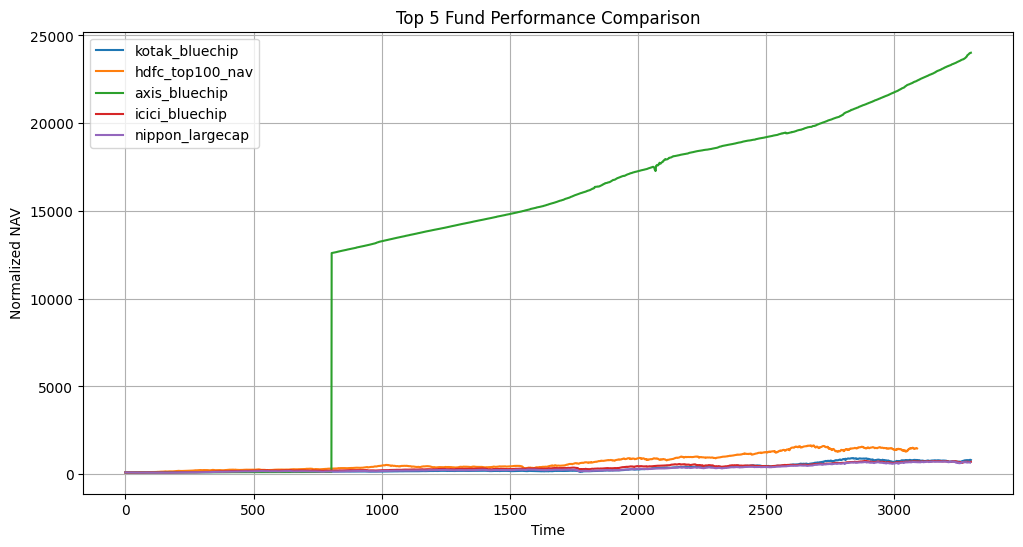

In [489]:
plt.figure(figsize=(12,6))

for fund in comparison_df.columns:
    plt.plot(
        comparison_df[fund],
        label=fund.replace(".csv","")
    )

plt.title(
    "Top 5 Fund Performance Comparison"
)

plt.xlabel("Time")
plt.ylabel("Normalized NAV")

plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/benchmark_comparison_chart.png"
)

plt.show()

In [490]:
import os

os.listdir("../reports")

['aum_growth.png',
 'gender_split.png',
 'benchmark_comparison_chart.png',
 'age_group_boxplot.png',
 'fund_scorecard.csv',
 'nav_trend.png',
 'data_quality_report.txt',
 'fund_master_analysis.txt',
 'download_datasets.py',
 'city_tier_distribution.png',
 'state_distribution.png',
 'age_group_pie.png',
 'alpha_beta.csv',
 'category_heatmap.png',
 'sip_trend.png',
 'return_distribution.png',
 'city_distribution.png',
 'fund_master_fetch.py']